# Exploratory Data Analysis of Large-Scale Examination Data

## Project Objective

The objective of this project is to analyze a large-scale examination dataset containing more than 2.3 million records and generate meaningful insights using Python-based Exploratory Data Analysis (EDA) techniques.

The analysis focuses on:
- Data cleaning
- Statistical analysis
- Visualization
- Outlier detection
- Performance comparison
- Insight generation

# 2. Import Required Libraries

In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# 3. Load Dataset

In [10]:

df = pd.read_csv("C:\\Users\\KAVITA\\Downloads\\archive (2)\\all_data.csv")

In [13]:
df.head(10)


,center_id,center_name,center_city,center_state,serial_no,score
0,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,1,42
1,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,2,172
2,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,3,42
3,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,4,222
4,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,5,129
5,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,6,63
6,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,7,501
7,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,8,46
8,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,9,335
9,272807,"KASTURBA GIRLS PU COLLEGE, KASTURBA GIRLS PU C...",SHIVAMOGA (SHIMOGA),KARNATAKA,10,66




# 4. Basic Dataset Information

In [17]:
print('Data_Shape :',df.shape)

Data_Shape : (2333162, 6)


In [21]:
print('\ncolumns:')
print(df.columns)



columns:
Index(['center_id', 'center_name', 'center_city', 'center_state', 'serial_no',
       'score'],
      dtype='object')


In [22]:
print('\nData Types:')
print(df.dtypes)



Data Types:
center_id        int64
center_name     object
center_city     object
center_state    object
serial_no        int64
score            int64
dtype: object


In [24]:
print('\nDataset Info')
print(df.info())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2333162 entries, 0 to 2333161
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   center_id     int64 
 1   center_name   object
 2   center_city   object
 3   center_state  object
 4   serial_no     int64 
 5   score         int64 
dtypes: int64(3), object(3)
memory usage: 106.8+ MB
None


# 5. Statistical Summary

In [26]:
df.describe()

,center_id,serial_no,score
count,2.333162e+06,2.333162e+06,2.333162e+06
mean,3.224020e+05,2.902341e+02,2.171566e+02
std,1.049598e+05,2.171436e+02,1.662400e+02
min,1.101010e+05,1.000000e+00,-1.800000e+02
25%,2.602020e+05,1.240000e+02,8.700000e+01
50%,3.111190e+05,2.510000e+02,1.630000e+02
75%,4.122060e+05,4.080000e+02,3.130000e+02
max,9.914010e+05,1.968000e+03,7.200000e+02


# 6. Check Missing Values

In [30]:
# Missing values counts
df.isnull().sum()


center_id         0
center_name       0
center_city       0
center_state    304
serial_no         0
score             0
dtype: int64

In [34]:
missing_percentage = (df.isnull().sum()/len(df)) * 100
print(missing_percentage)

center_id       0.00000
center_name     0.00000
center_city     0.00000
center_state    0.01303
serial_no       0.00000
score           0.00000
dtype: float64


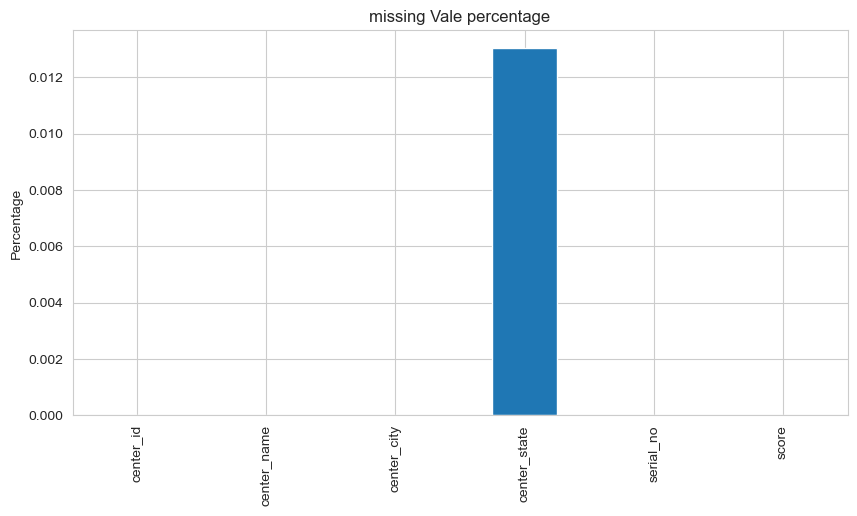

In [36]:
plt.figure(figsize=(10,5))
missing_percentage.plot(kind='bar')
plt.title('missing Vale percentage')
plt.ylabel('Percentage')
plt.show()

# 7. Duplicate Records Analysis

In [37]:
duplicates = df.duplicated().sum()
print(duplicates)

0


# 8. Unique Values Analysis

In [40]:
for col in df.columns:
    print(f'\ncolumn :{col}')
    print('Unique Values:', df[col].nunique())


column :center_id
Unique Values: 4750

column :center_name
Unique Values: 4748

column :center_city
Unique Values: 585

column :center_state
Unique Values: 51

column :serial_no
Unique Values: 1968

column :score
Unique Values: 800


# 9. Univariate Analysis

This section analyzes the distribution and spread of examination scores.

Text(0, 0.5, 'Frequency')

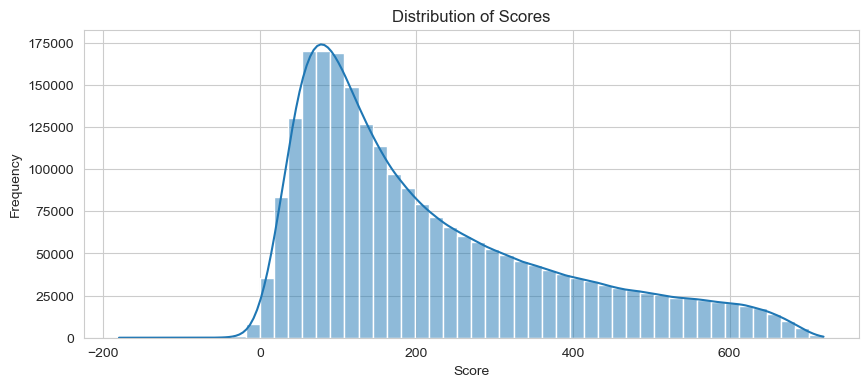

In [42]:
# 9.1 Score Distribution
plt.figure(figsize = (10,4))
sns.histplot(df['score'],bins = 50 , kde= True)
plt.title("Distribution of Scores")
plt.xlabel('Score')
plt.ylabel('Frequency')

## Insight

The score distribution is not perfectly uniform, indicating varying levels of student performance across examination centers.

The presence of concentration zones suggests that a large number of students fall within a limited score range, while fewer students achieve extremely high or low scores.

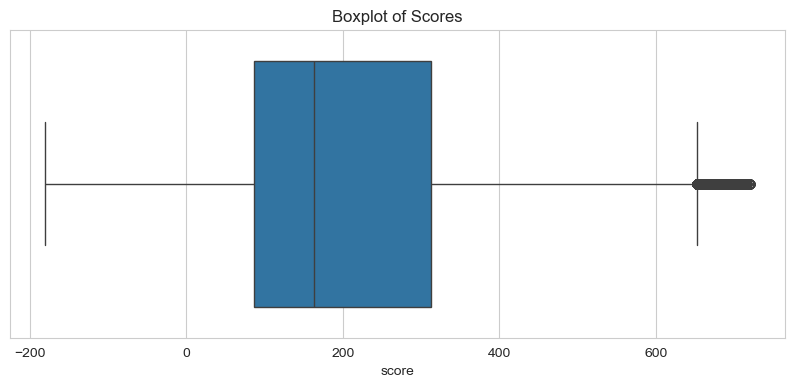

In [44]:
# 9.2 Boxplot for Score
plt.figure(figsize = (10,4))
sns.boxplot(x=df['score'])
plt.title('Boxplot of Scores')
plt.show()

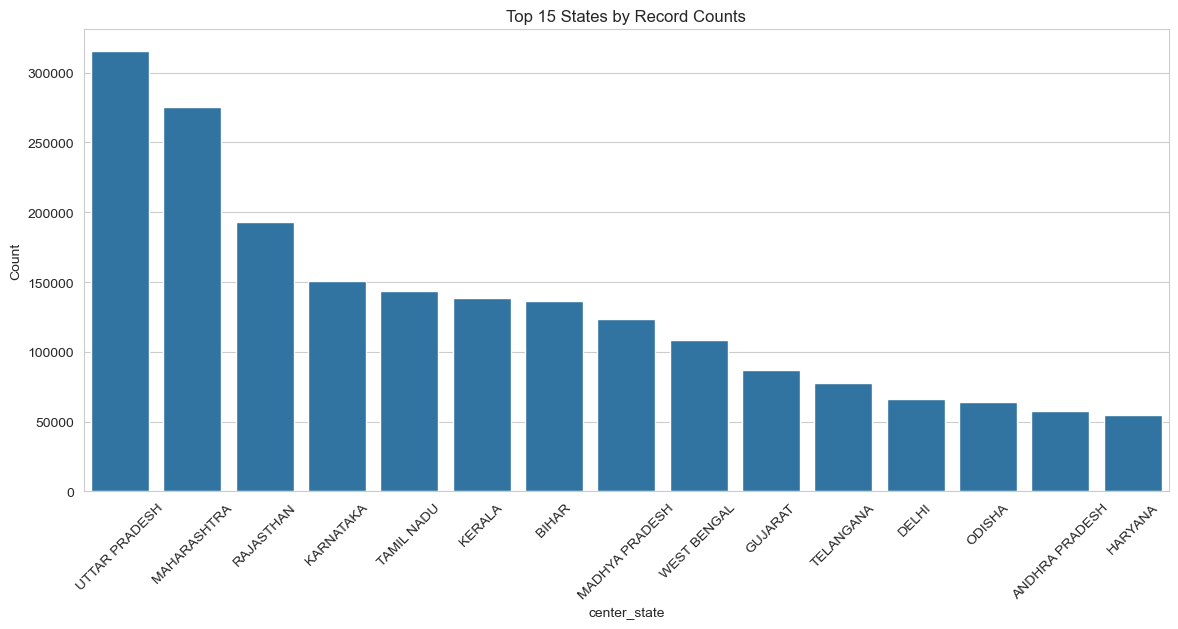

In [48]:
# 9.3 State-wise Record Count
State_counts = df['center_state'].value_counts().head(15)
plt.figure(figsize = (14,6))
sns.barplot(x=State_counts.index ,y=State_counts.values)
plt.xticks(rotation = 45)
plt.title('Top 15 States by Record Counts')
plt.ylabel('Count')
plt.show()

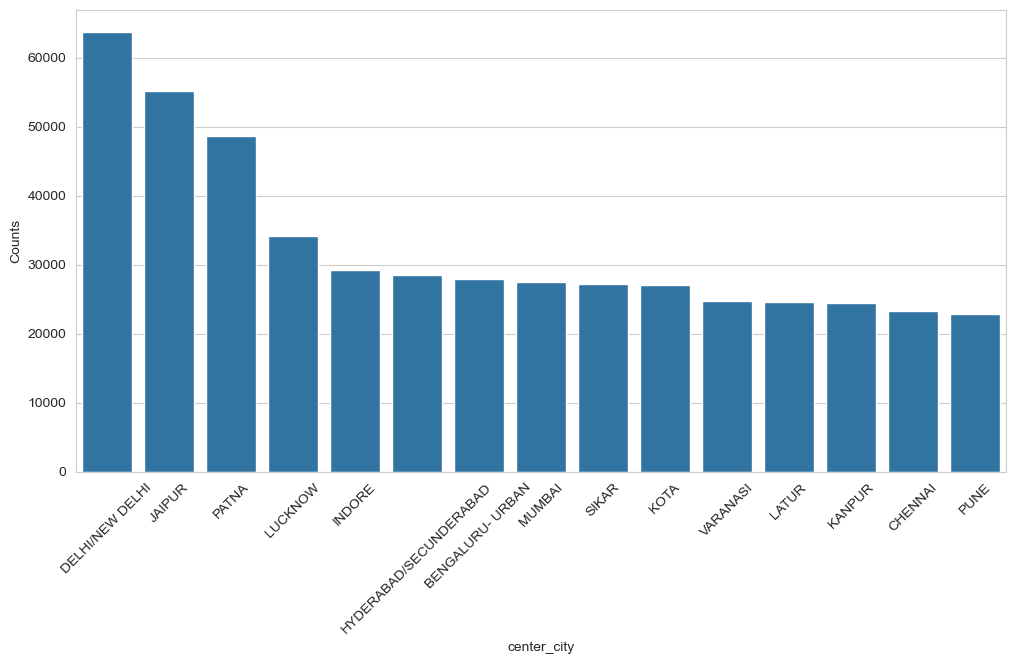

In [51]:
# 9.4 City-wise Record Count
city_counts = df['center_city'].value_counts().head(15)
plt.figure(figsize = (12,6))
sns.barplot(x=city_counts.index,y=city_counts.values)
plt.xticks(rotation = 45)
plt.ylabel('Counts')
plt.show()

In [57]:
df.columns

Index(['center_id', 'center_name', 'center_city', 'center_state', 'serial_no',
       'score'],
      dtype='object')

# 10. Bivariate Analysis

This section compares performance across states, cities, and examination centers.

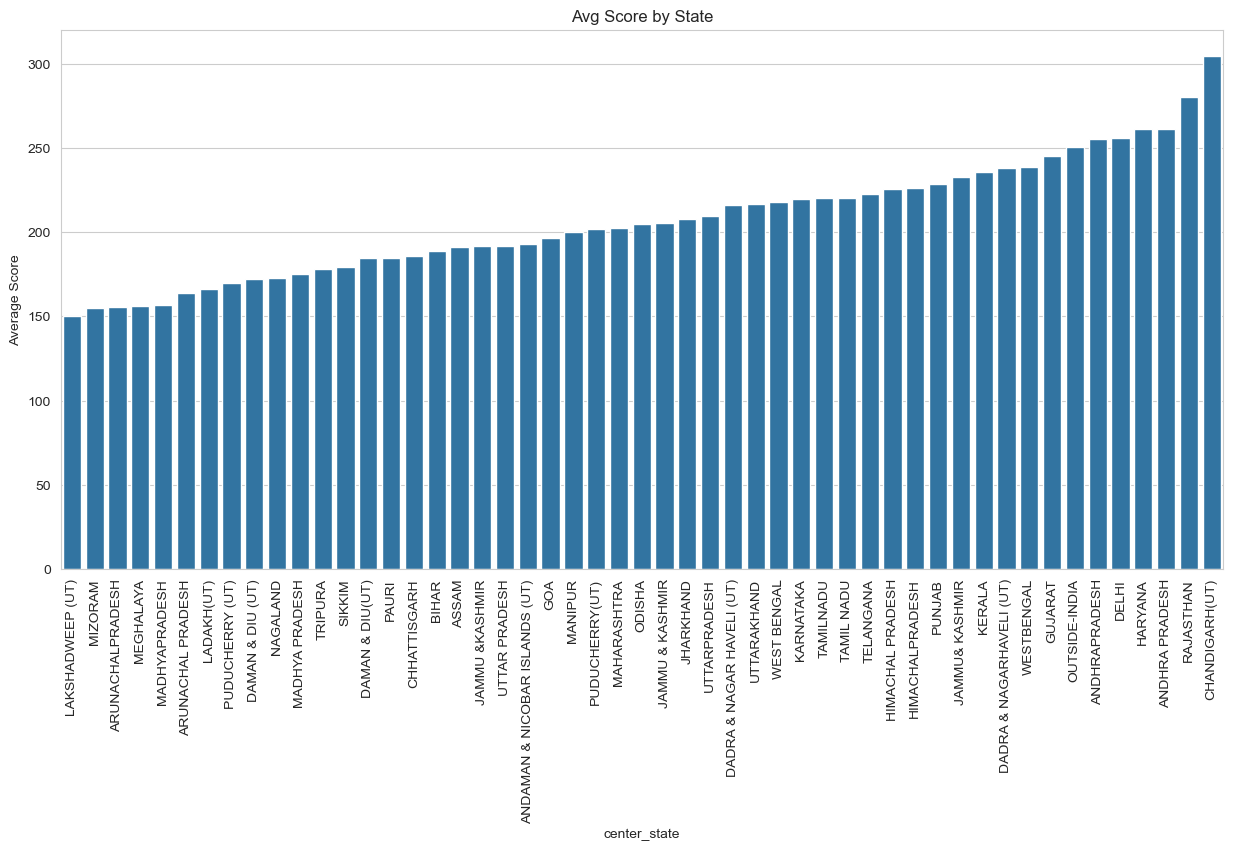

In [62]:
# 10.1 Average Score by State
state_avg_score = df.groupby('center_state')['score'].mean().sort_values(ascending = True)
plt.figure(figsize = (15,7))
sns.barplot(x=state_avg_score.index , y= state_avg_score.values)
plt.xticks(rotation= 90)
plt.title("Avg Score by State")
plt.ylabel('Average Score')
plt.show()


## Insight

Average scores vary significantly across states, suggesting possible differences in:
- educational infrastructure,
- student preparation levels,
- examination center quality,
- or regional academic competitiveness.

Certain states consistently demonstrate stronger overall performance.

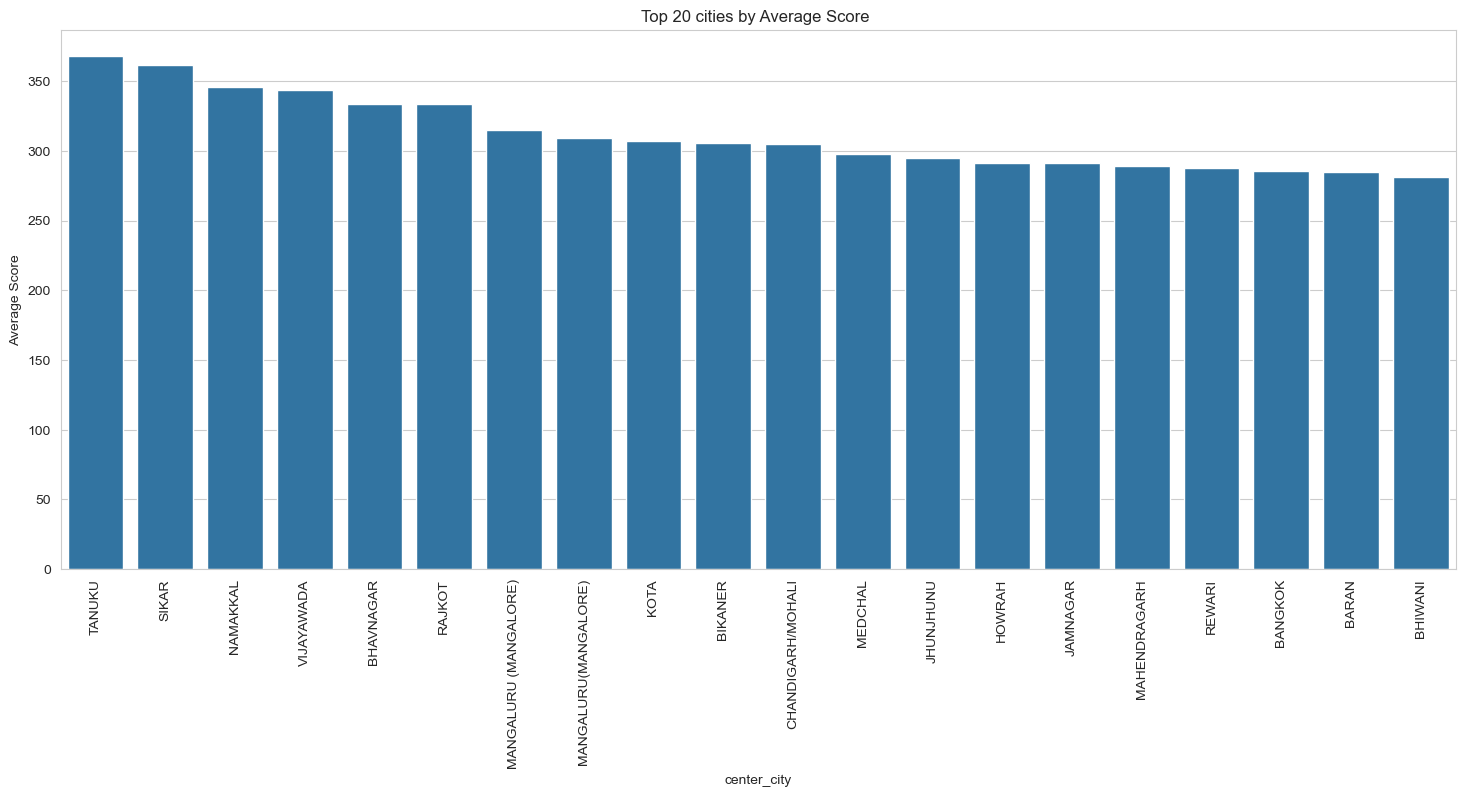

In [91]:
# 10.2 Average Score by City
city_avg_score = df.groupby('center_city')['score'].mean().sort_values(ascending = False).head(20)
plt.figure(figsize = (18,7))
plt.tight_layout()
sns.barplot(x=city_avg_score.index , y= city_avg_score.values)
plt.xticks(rotation= 90)
plt.title("Top 20 cities by Average Score ")
plt.ylabel('Average Score')
plt.show()


## Insight

Some cities show higher average scores compared to others, indicating localized performance advantages.

This may reflect:
- concentration of better institutions,
- access to academic resources,
- or stronger competitive environments.

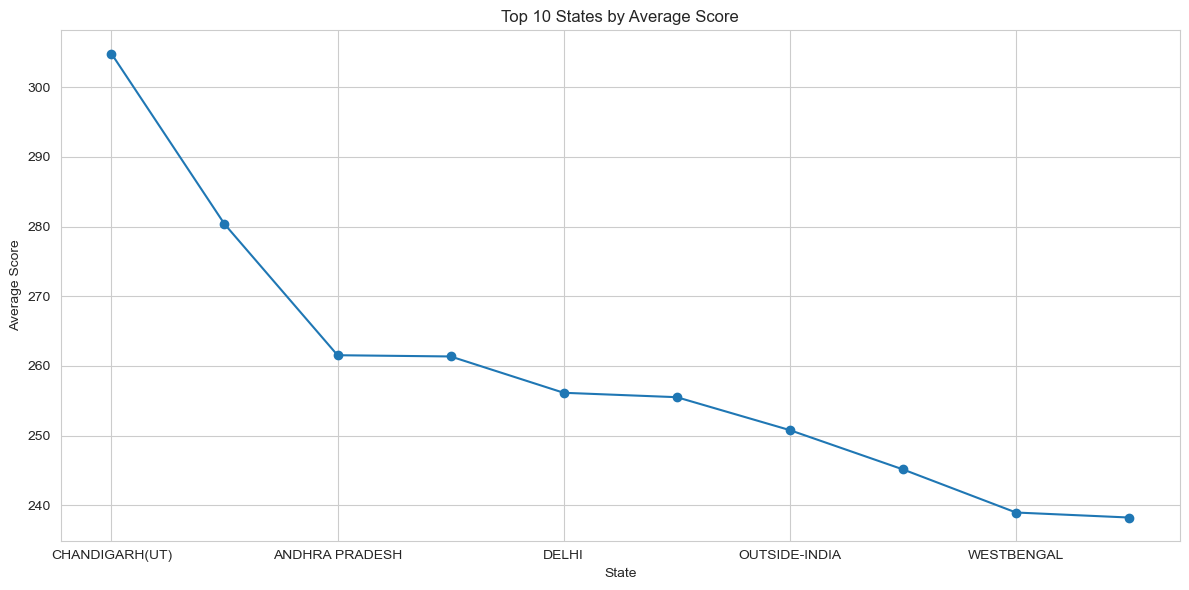

In [94]:
top_states = (
    df.groupby('center_state')['score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(kind='line', marker='o')

plt.title('Top 10 States by Average Score')
plt.ylabel('Average Score')
plt.xlabel('State')

plt.grid(True)
plt.tight_layout()
plt.show()

## Insight

The chart shows clear variation in average scores across states. CHANDIGARH (UT) recorded the highest average score, while other states showed comparatively lower but closely distributed performance levels. This indicates regional differences in examination performance and academic competitiveness.

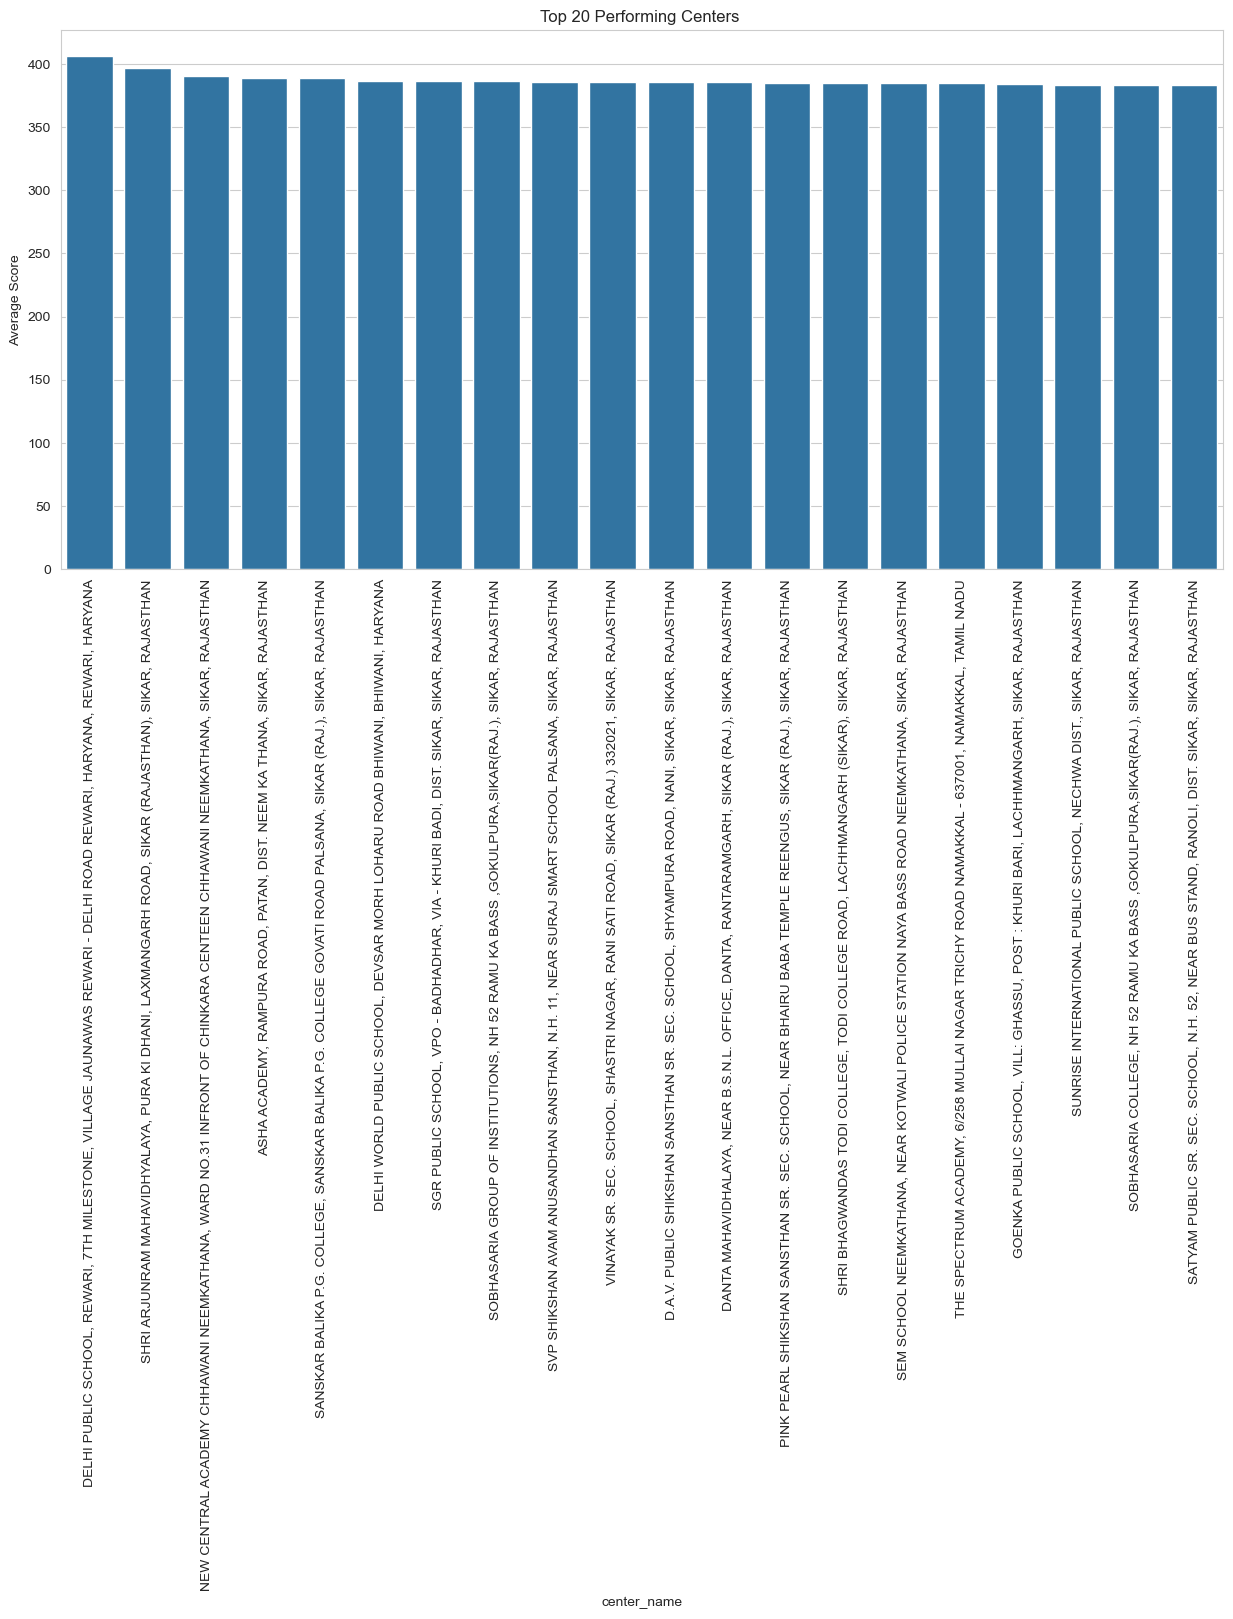

In [67]:
# 10.3 Top Performing Centers
center_avg = df.groupby('center_name')['score'].mean().sort_values(ascending = False).head(20)
plt.figure(figsize = (15,7))
sns.barplot(x=center_avg.index , y= center_avg.values)
plt.xticks(rotation= 90)
plt.title("Top 20 Performing Centers ")
plt.ylabel('Average Score')
plt.show()


## Insight

Performance differences between examination centers reveal measurable variation in student outcomes.

High-performing centers may serve as benchmarks for operational and academic best practices, while low-performing centers may require additional investigation.

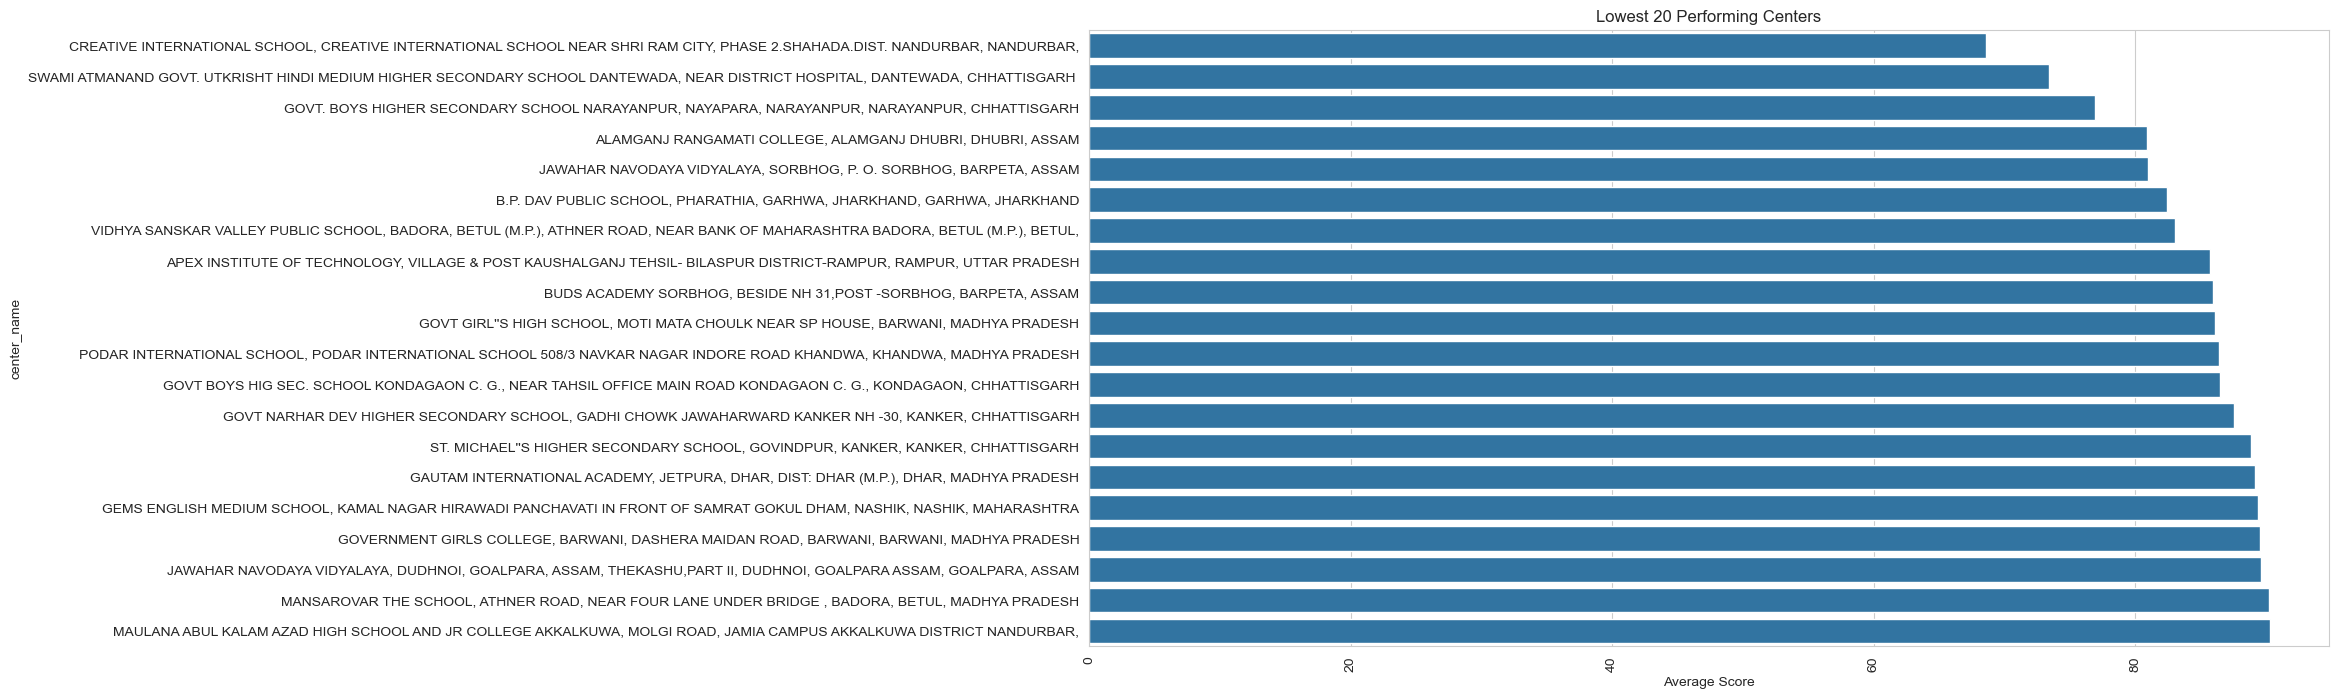

In [70]:
# 10.4 Lowest Performing Centers
low_center_avg = (
    df.groupby('center_name')['score']
    .mean()
    .sort_values(ascending=True)
    .head(20)
)

plt.figure(figsize=(16,8))

sns.barplot(x=low_center_avg.values,
            y=low_center_avg.index)
plt.xticks(rotation = 90)

plt.title('Lowest 20 Performing Centers')
plt.xlabel('Average Score')
plt.show()

In [71]:
# 11. Outlier Detection
z_scores = np.abs(stats.zscore(df['score']))

outliers = df[z_scores > 3]

print('Number of Outliers:', len(outliers))

Number of Outliers: 71


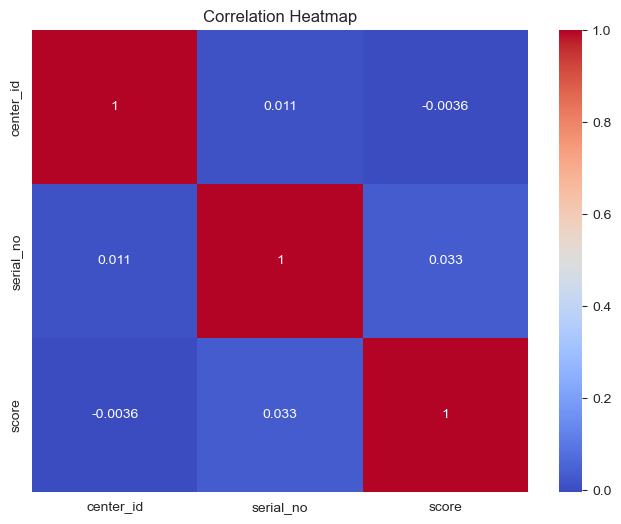

In [73]:
# 12. Correlation Analysis
numerical_df = df.select_dtypes(include = np.number)
correlation_matrix = numerical_df.corr()
plt.figure(figsize = (8,6))
sns.heatmap(correlation_matrix,annot = True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 13. Feature Engineering

In [77]:
def score_category(score):
    if score >= 250:
        return 'Excellent'
    elif score >= 180:
        return 'Good'
    elif score >= 100:
        return 'Average'
    else:
        return 'Poor'

df['score_category'] = df['score'].apply(score_category)
print(df['score_category'].value_counts())

score_category
Excellent    781415
Poor         693457
Average      560336
Good         297954
Name: count, dtype: int64


## Insight

Categorizing scores into performance groups improves interpretability and supports higher-level business analysis.

This transformation enables easier reporting and segmentation of student performance levels.

# 14. Score Category Visualization

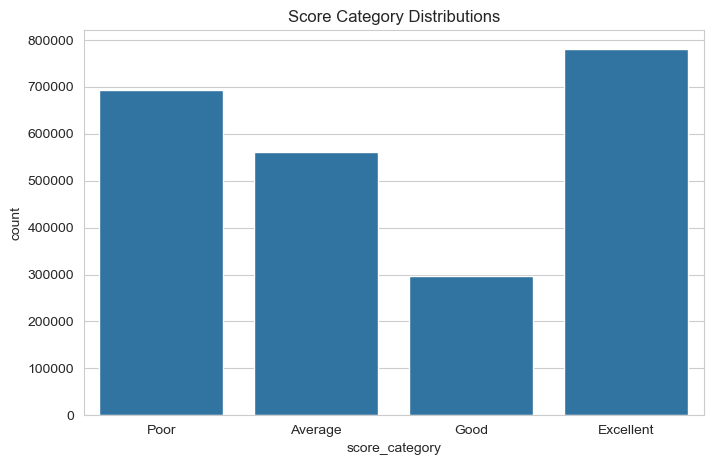

In [78]:
plt.figure(figsize = (8,5))
sns.countplot(x='score_category',data=df)
plt.title("Score Category Distributions")
plt.show()


# 15. Advanced Analysis

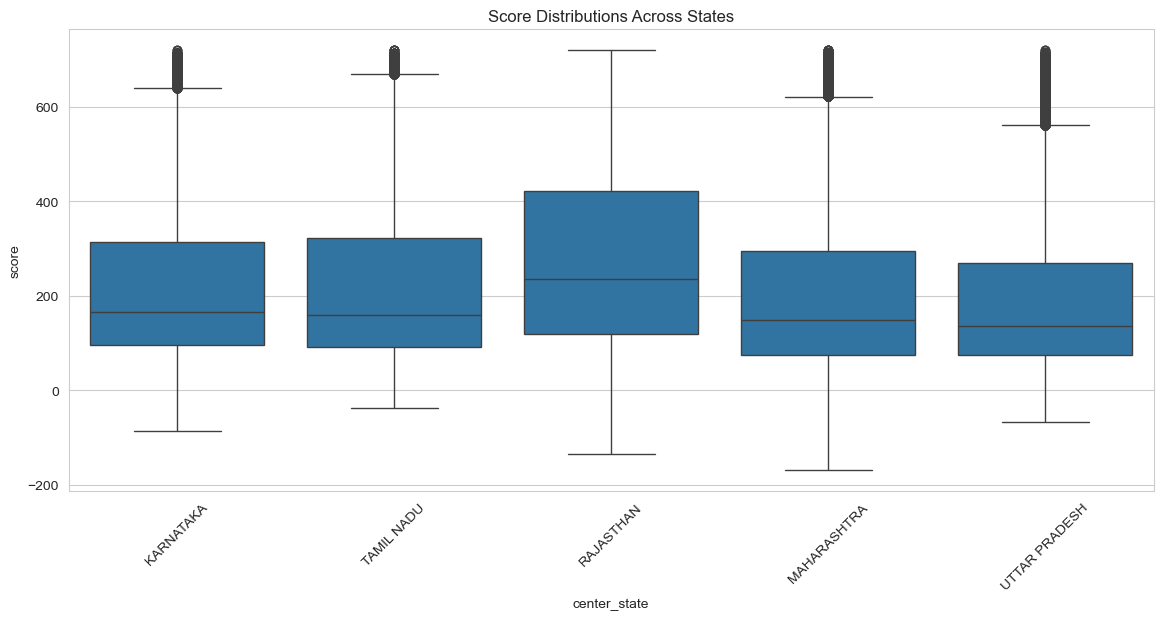

In [85]:
# 15.1 State-wise Score Distribution
top_states = df['center_state'].value_counts().head(5).index
filtered_df = df[df['center_state'].isin(top_states)]
plt.figure(figsize=(14,6))
sns.boxplot(x='center_state' , y='score',data = filtered_df)
plt.xticks(rotation = 45)
plt.title('Score Distributions Across States')
plt.show()

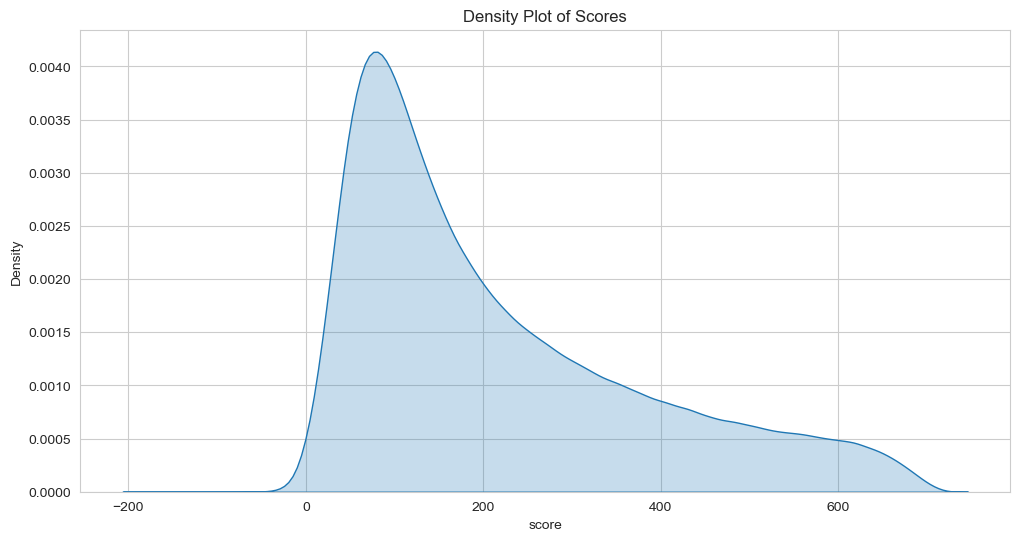

In [88]:
# 15.2 Student Density by Score
plt.figure(figsize= (12,6))
sns.kdeplot(df['score'],fill = True)
plt.title('Density Plot of Scores')
plt.show()

## Final Insights

This project demonstrates how Exploratory Data Analysis (EDA) can transform large raw datasets into meaningful analytical insights.

The analysis identified:
- performance variation across regions,
- score distribution patterns,
- outliers,
- and operational benchmarking opportunities.

The project also highlights the importance of scalable data processing techniques when working with multi-million-row datasets.

In [90]:
# =========================================
# Final Conclusion
# =========================================

print("""
EDA Project Completed Successfully

Key Achievements:
✔ Data Cleaning & Preprocessing
✔ Missing Value Analysis
✔ Duplicate Detection
✔ Statistical Analysis
✔ Data Visualization
✔ Outlier Detection
✔ State-wise Performance Analysis
✔ Center-wise Performance Insights
✔ Feature Engineering

Tools & Libraries Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy

This project demonstrates practical Exploratory Data Analysis (EDA)
skills on a large-scale dataset containing more than 2.3 million records.
""")


EDA Project Completed Successfully

Key Achievements:
✔ Data Cleaning & Preprocessing
✔ Missing Value Analysis
✔ Duplicate Detection
✔ Statistical Analysis
✔ Data Visualization
✔ Outlier Detection
✔ State-wise Performance Analysis
✔ Center-wise Performance Insights
✔ Feature Engineering

Tools & Libraries Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy

This project demonstrates practical Exploratory Data Analysis (EDA)
skills on a large-scale dataset containing more than 2.3 million records.



# Thank You

## Author
Yogesh Kumar

## Connect With Me
- LinkedIn: https://www.linkedin.com/in/yogeshkumar-data-analyst/
- GitHub: https://github.com/yogeshkumar70628